In [1]:
# =========================================
# 1. Imports
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import joblib

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


In [2]:
# =========================================
# 2. Load dataset
# =========================================
# Preferred: processed file from EDA
PROCESSED_PATH = Path("../data/processed/airlines_delay_eda.csv")
RAW_PATH = Path("../data/raw/airlines_delay.csv")

if PROCESSED_PATH.exists():
    DATA_PATH = PROCESSED_PATH
elif RAW_PATH.exists():
    DATA_PATH = RAW_PATH
else:
    raise FileNotFoundError(
        "No dataset found. Expected one of these paths:\n"
        f"- {PROCESSED_PATH}\n"
        f"- {RAW_PATH}"
    )

df = pd.read_csv(DATA_PATH)

print("Loaded from:", DATA_PATH)
print("Shape:", df.shape)
display(df.head())


Loaded from: ..\data\processed\airlines_delay_eda.csv
Shape: (539383, 7)


,Airline,AirportFrom,AirportTo,DayOfWeek,Length,DepartureHour,Delay
0,CO,SFO,IAH,3,205,0,1
1,US,PHX,CLT,3,222,0,1
2,AA,LAX,DFW,3,165,0,1
3,AA,SFO,DFW,3,195,0,1
4,AS,ANC,SEA,3,202,0,0


In [3]:
# =========================================
# 3. Prepare dataset
# =========================================
# If raw dataset is used, create DepartureHour as fallback.
# Note: Time is minutes since midnight (0=00:00, 1439=23:59).
if "DepartureHour" not in df.columns and "Time" in df.columns:
    df["DepartureHour"] = df["Time"] // 60

# Drop columns not used in this model
drop_columns = ["id", "Flight", "Time", "DepartureMinute", "IsWeekend", "LengthBin", "Route"]
existing_drop_columns = [col for col in drop_columns if col in df.columns]

df = df.drop(columns=existing_drop_columns, errors="ignore")

print("Columns after preparation:")
print(df.columns.tolist())
display(df.head())


Columns after preparation:
['Airline', 'AirportFrom', 'AirportTo', 'DayOfWeek', 'Length', 'DepartureHour', 'Delay']


,Airline,AirportFrom,AirportTo,DayOfWeek,Length,DepartureHour,Delay
0,CO,SFO,IAH,3,205,0,1
1,US,PHX,CLT,3,222,0,1
2,AA,LAX,DFW,3,165,0,1
3,AA,SFO,DFW,3,195,0,1
4,AS,ANC,SEA,3,202,0,0


In [4]:
# =========================================
# 4. Define features and target
# =========================================
TARGET = "Delay"

X = df.drop(columns=[TARGET])
y = df[TARGET]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
display(y.value_counts())
display((y.value_counts(normalize=True) * 100).round(2))


Feature shape: (539383, 6)
Target shape: (539383,)

Target distribution:


Delay
0    299119
1    240264
Name: count, dtype: int64

Delay
0    55.46
1    44.54
Name: proportion, dtype: float64

In [5]:
# =========================================
# 5. Define feature types
# =========================================
# IsWeekend is excluded: it is redundant with DayOfWeek (already encoded below).
categorical_features = [col for col in ["Airline", "AirportFrom", "AirportTo", "DayOfWeek"] if col in X.columns]
numeric_features = [col for col in ["Length", "DepartureHour"] if col in X.columns]

print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)


Categorical features: ['Airline', 'AirportFrom', 'AirportTo', 'DayOfWeek']
Numeric features: ['Length', 'DepartureHour']


In [6]:
# =========================================
# 6. Train-test split
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (431506, 6)
X_test : (107877, 6)
y_train: (431506,)
y_test : (107877,)


In [7]:
# =========================================
# 7. Preprocessing pipeline
# =========================================
# Note: OHE on AirportFrom + AirportTo produces ~586 sparse columns (293 airports each).
# Plus ~18 Airline columns and 7 DayOfWeek columns.
# Total feature space is large but manageable for LogisticRegression.
# Tree-based models in notebook 03 will handle high cardinality more naturally.
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Length', 'DepartureHour']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Airline', 'AirportFrom', 'AirportTo',
                                  'DayOfWeek'])])

In [8]:
# =========================================
# 8. Baseline model pipeline
# =========================================
# class_weight=None (default) because target is only mildly imbalanced (55/45).
# We will revisit with class_weight='balanced' in notebook 03 if needed.
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

baseline_model


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Length', 'DepartureHour']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Airline', 'AirportFrom',
                                                   'AirportTo',
                                                   'DayOfWeek'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [9]:
# =========================================
# 9. Train baseline model
# =========================================
baseline_model.fit(X_train, y_train)

print("Baseline model trained successfully.")


Baseline model trained successfully.


In [10]:
# =========================================
# 10. Predictions
# =========================================
y_pred = baseline_model.predict(X_test)
y_proba = baseline_model.predict_proba(X_test)[:, 1]

predictions_df = X_test.copy()
predictions_df["actual"] = y_test.values
predictions_df["predicted"] = y_pred
predictions_df["probability_delay"] = y_proba

display(predictions_df.head())


,Airline,AirportFrom,AirportTo,DayOfWeek,Length,DepartureHour,actual,predicted,probability_delay
209025,OO,HPN,ORD,1,156,8,0,0,0.401366
414052,US,OAK,PHX,5,111,16,0,0,0.408148
134096,MQ,DFW,SGF,3,75,17,1,0,0.393318
410700,CO,SNA,IAH,5,188,12,1,1,0.516901
229055,AA,DFW,ELP,2,105,10,0,0,0.327014


In [11]:
# =========================================
# 11. Evaluate baseline model
# =========================================
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_proba)

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Value": [accuracy, precision, recall, f1, roc_auc]
})

display(metrics_df)
print(classification_report(y_test, y_pred, zero_division=0))


,Metric,Value
0,Accuracy,0.646394
1,Precision,0.634529
2,Recall,0.486213
3,F1 Score,0.550557
4,ROC-AUC,0.692075


              precision    recall  f1-score   support

           0       0.65      0.78      0.71     59824
           1       0.63      0.49      0.55     48053

    accuracy                           0.65    107877
   macro avg       0.64      0.63      0.63    107877
weighted avg       0.64      0.65      0.64    107877



,Predicted 0,Predicted 1
Actual 0,46367,13457
Actual 1,24689,23364


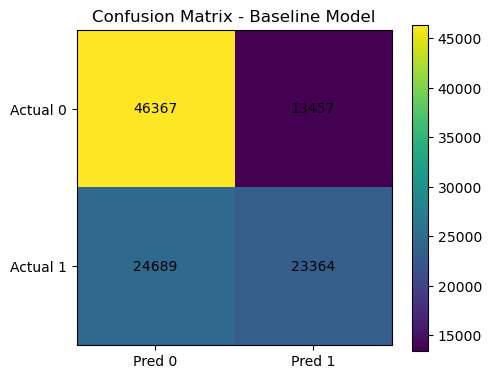

In [12]:
# =========================================
# 12. Confusion matrix
# =========================================
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

display(cm_df)

plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix - Baseline Model")
plt.colorbar()
plt.xticks([0, 1], ["Pred 0", "Pred 1"])
plt.yticks([0, 1], ["Actual 0", "Actual 1"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


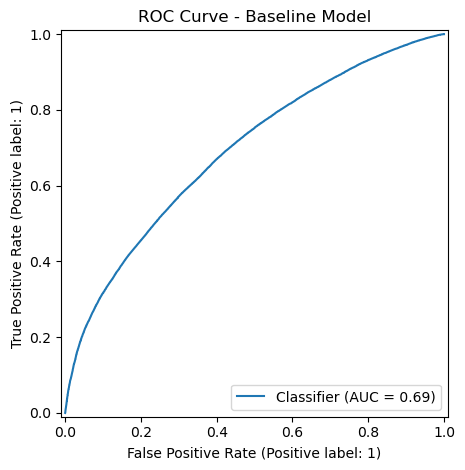

In [13]:
# =========================================
# 13. ROC curve
# =========================================
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve - Baseline Model")
plt.tight_layout()
plt.show()


In [14]:
# =========================================
# 14. Inspect predicted probabilities
# =========================================
predictions_sorted = predictions_df.sort_values("probability_delay", ascending=False)
display(predictions_sorted.head(20))


,Airline,AirportFrom,AirportTo,DayOfWeek,Length,DepartureHour,actual,predicted,probability_delay
344560,WN,MDW,SFO,1,305,19,0,1,0.934853
153551,WN,MDW,SFO,4,305,19,1,1,0.929100
66789,WN,MDW,SFO,6,300,19,0,1,0.914241
461395,WN,MDW,SFO,1,300,15,1,1,0.914077
415531,WN,MDW,SFO,5,300,17,1,1,0.908130
17194,WN,LAX,SFO,3,75,21,1,1,0.906881
223116,WN,LAX,SFO,1,75,21,1,1,0.906633
503015,WN,MDW,SEA,3,285,19,0,1,0.906444
344544,WN,MDW,SEA,1,285,19,0,1,0.906195
276214,WN,DEN,SFO,4,175,21,1,1,0.905004


In [15]:
# =========================================
# 15. Save baseline model
# =========================================
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODELS_DIR / "baseline_model.pkl"
joblib.dump(baseline_model, MODEL_PATH)

print(f"Baseline model saved to: {MODEL_PATH}")


Baseline model saved to: ..\models\baseline_model.pkl


In [ ]:
# =========================================
# 16. Save baseline metrics
# =========================================
OUTPUT_DIR = Path("../data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

METRICS_PATH = OUTPUT_DIR / "baseline_metrics.csv"
PREDICTIONS_PATH = OUTPUT_DIR / "baseline_predictions_sample.csv"

metrics_df.to_csv(METRICS_PATH, index=False)
predictions_df.head(100).to_csv(PREDICTIONS_PATH, index=False)

print(f"Saved metrics to: {METRICS_PATH}")
print(f"Saved prediction sample to: {PREDICTIONS_PATH}")


Saved metrics to: ..\data\processed\baseline_metrics.csv
Saved prediction sample to: ..\data\processed\baseline_predictions_sample.csv


In [17]:
# =========================================
# 17. Final summary for presentation
# =========================================
print("BASELINE MODEL SUMMARY")
print("----------------------")
print("Model: Logistic Regression")
print(f"Dataset used: {DATA_PATH}")
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print()
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print()
print("Features used:")
for col in X.columns:
    print("-", col)


BASELINE MODEL SUMMARY
----------------------
Model: Logistic Regression
Dataset used: ..\data\processed\airlines_delay_eda.csv
Train shape: (431506, 6)
Test shape: (107877, 6)

Accuracy : 0.6464
Precision: 0.6345
Recall   : 0.4862
F1 Score : 0.5506
ROC-AUC  : 0.6921

Features used:
- Airline
- AirportFrom
- AirportTo
- DayOfWeek
- Length
- DepartureHour
